# Meteorological Risk Factors for Plasmopara viticola Infection in European Vineyards
## A Data Science Analysis of Disease Occurrence and Meteorological Conditions

**SoftUni Data Science Program — Final Exam Project**  
**Author:** Pavel Ivanov  


## 1. Setup - Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import folium

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

warnings.filterwarnings("ignore")

# Bordeaux dataset
bordeaux = pd.read_excel('../data/raw/plosone_bordeaux_downy_mildew_s1.xlsx')

print(f"Shape: {bordeaux.shape}")
print(f"\nColumns:\n{list(bordeaux.columns)}")
bordeaux.head()

Shape: (156, 15)

Columns:
['Id_Parc', 'Date_App', 'Year', 'Mar_p_total_moy', 'Apr_p_total_moy', 'May_p_total_moy', 'Jun_p_total_moy', 'Mar_tmean_h_q_moy', 'Apr_tmean_h_q_moy', 'May_tmean_h_q_moy', 'Jun_tmean_h_q_moy', 'MFF_fin', 'MFI_fin', 'MGF_fin', 'MGI_fin']


,Id_Parc,Date_App,Year,Mar_p_total_moy,Apr_p_total_moy,May_p_total_moy,Jun_p_total_moy,Mar_tmean_h_q_moy,Apr_tmean_h_q_moy,May_tmean_h_q_moy,Jun_tmean_h_q_moy,MFF_fin,MFI_fin,MGF_fin,MGI_fin
0,1,22.0,2,0.764516,0.343333,0.387097,1.090000,10.337097,15.531667,18.666129,18.940000,0.0,0.0,0,0.0
1,2,24.0,3,0.777419,5.503333,1.535484,2.336667,11.017742,10.560000,16.938710,19.746667,1.0,1.0,1,1.0
2,3,25.0,2,0.777419,0.350000,0.387097,1.100000,10.206452,15.410000,18.498387,18.793333,0.0,1.0,0,0.0
3,4,22.0,3,0.787097,5.553333,1.554839,2.363333,10.930645,10.378333,16.730645,19.536667,1.0,1.0,1,1.0
4,5,25.0,4,2.045161,1.623333,3.377419,4.063333,8.727419,11.528333,12.682258,17.026667,0.0,0.0,0,0.0


In [12]:
bordeaux.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Id_Parc            156 non-null    int64  
 1   Date_App           156 non-null    float64
 2   Year               156 non-null    int64  
 3   Mar_p_total_moy    156 non-null    float64
 4   Apr_p_total_moy    156 non-null    float64
 5   May_p_total_moy    156 non-null    float64
 6   Jun_p_total_moy    156 non-null    float64
 7   Mar_tmean_h_q_moy  156 non-null    float64
 8   Apr_tmean_h_q_moy  156 non-null    float64
 9   May_tmean_h_q_moy  156 non-null    float64
 10  Jun_tmean_h_q_moy  156 non-null    float64
 11  MFF_fin            151 non-null    float64
 12  MFI_fin            150 non-null    float64
 13  MGF_fin            156 non-null    int64  
 14  MGI_fin            151 non-null    float64
dtypes: float64(12), int64(3)
memory usage: 18.4 KB


In [13]:
bordeaux.describe().round(2)

,Id_Parc,Date_App,Year,Mar_p_total_moy,Apr_p_total_moy,May_p_total_moy,Jun_p_total_moy,Mar_tmean_h_q_moy,Apr_tmean_h_q_moy,May_tmean_h_q_moy,Jun_tmean_h_q_moy,MFF_fin,MFI_fin,MGF_fin,MGI_fin
count,156.00,156.00,156.00,156.00,156.00,156.00,156.00,156.00,156.00,156.00,156.00,151.0,150.0,156.0,151.0
mean,78.50,24.72,4.59,1.98,2.29,2.11,2.42,9.67,12.70,15.87,19.32,0.5,0.5,0.5,0.5
std,45.18,4.27,2.38,1.02,1.71,1.09,0.85,0.97,1.67,1.77,1.25,0.5,0.5,0.5,0.5
min,1.00,19.00,1.00,0.43,0.20,0.14,0.63,7.97,10.01,12.21,16.91,0.0,0.0,0.0,0.0
25%,39.75,22.00,3.00,0.92,1.05,1.43,1.80,8.82,11.42,14.60,18.63,0.0,0.0,0.0,0.0
50%,78.50,23.00,4.00,2.02,2.09,2.15,2.34,9.68,12.56,16.03,19.07,1.0,0.5,0.5,1.0
75%,117.25,26.25,7.00,2.71,2.57,3.01,2.94,10.36,13.64,16.95,20.35,1.0,1.0,1.0,1.0
max,156.00,33.00,9.00,4.34,6.55,4.44,4.46,11.79,16.45,19.11,21.56,1.0,1.0,1.0,1.0


In [14]:
# Missing values
missing = bordeaux.isnull().sum()
missing[missing > 0]

MFF_fin    5
MFI_fin    6
MGI_fin    5
dtype: int64

### Observation from `.describe()`

The dataset contains 156 site-year records. Weather variables (precipitation and mean temperature for March–June) have no missing values. The four binary disease outcome variables — MFF_fin, MFI_fin, MGF_fin, MGI_fin — each have 5–6 missing entries and are perfectly balanced (mean ≈ 0.5), suggesting the dataset was stratified by disease outcome during collection. Year ranges from 1 to 9, corresponding to 2010–2018.

### Missing Value Startegy

Missing values affect only the target columns (5-6 rows each; less than 4% of data).
Since these rows still contain valid weather data, we retain them for weather analysis but will exclude them when training classification models.

## 2. Exploratory Data Analysis (EDA)

### 2.1 Disease Outcome Distribution

We first examine how often high disease incidence was recorded across the four outcome variables. All four are binary: 0 = low incidence, 1 = high incidence.

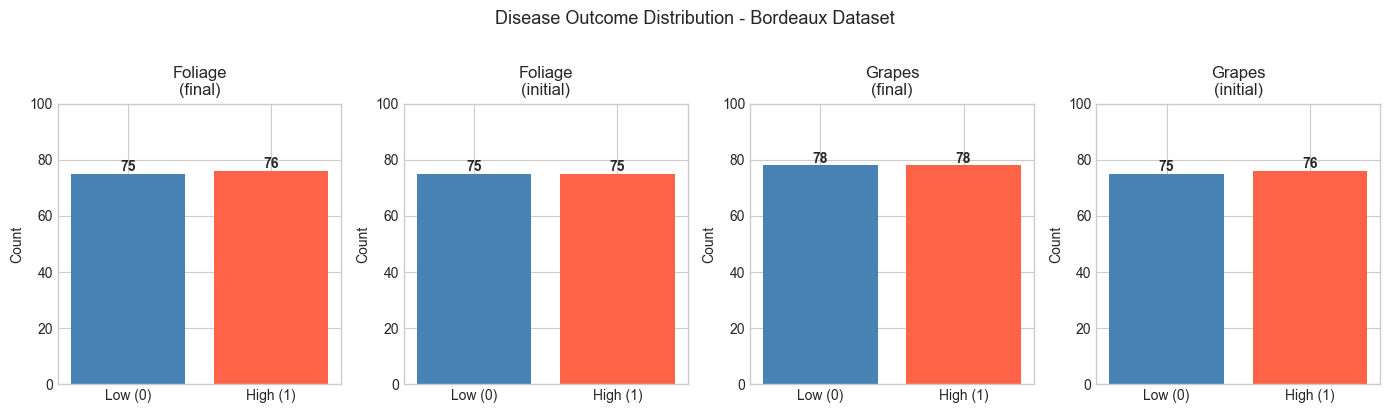

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

targets = ['MFF_fin', 'MFI_fin', 'MGF_fin', 'MGI_fin']
labels = ['Foliage\n(final)', 'Foliage\n(initial)', 'Grapes\n(final)', 'Grapes\n(initial)']

for ax, col, label in zip(axes, targets, labels):
    counts = bordeaux[col].value_counts().sort_index()
    ax.bar(['Low (0)', 'High (1)'], counts.values, color=['steelblue', 'tomato'])
    ax.set_title(label)
    ax.set_ylabel('Count')
    ax.set_ylim(0, 100)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.suptitle('Disease Outcome Distribution - Bordeaux Dataset', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

All four outcome variables are nearly perfectly balanced: each shows approximately 75-78 records per class. This confirms the stratifiednature of the dataset noted in the original study - the 50/50 split was by design, not a natural occurence rate

### 2.2 Weather Variable Distributions

Distribution of monthly precipitation and mean temperatre accross all site-years (March-June). These are the predictor variables used in the subsequent analysis.

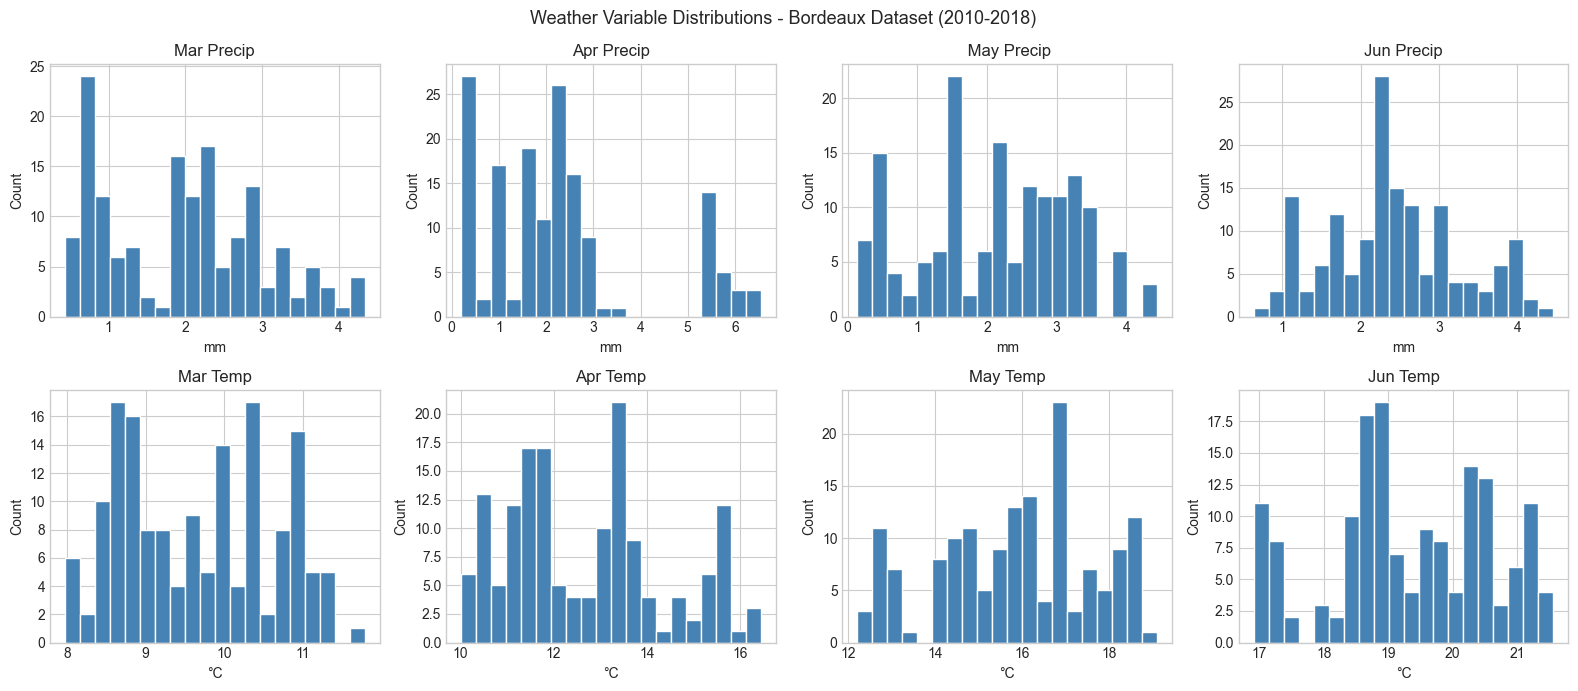

In [21]:
weather_cols = [
    'Mar_p_total_moy', 'Apr_p_total_moy', 'May_p_total_moy', 'Jun_p_total_moy',
    'Mar_tmean_h_q_moy', 'Apr_tmean_h_q_moy', 'May_tmean_h_q_moy', 'Jun_tmean_h_q_moy'
]

col_labels = [
    'Mar Precip', 'Apr Precip', ' May Precip', 'Jun Precip',
    'Mar Temp', 'Apr Temp', 'May Temp', 'Jun Temp'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, col, label in zip(axes.flatten(), weather_cols, col_labels):
    ax.hist(bordeaux[col], bins=20, color='steelblue', edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('mm' if 'Precip' in label else '°C')
    ax.set_ylabel('Count')

plt.suptitle("Weather Variable Distributions - Bordeaux Dataset (2010-2018)", fontsize=13)
plt.tight_layout()
plt.show()

Precipitation distributions are right-skewed across all months, with most site-years recording low monthly totals and fewer recording high rainfall events. Temperature distributions are approximately bell-shaped and show a clear seasonal progression:
March (8–12 °C) → April (10–16 °C) → May (12–19 °C) → June (17–22 °C),
consistent with the Bordeaux climate. No extreme outliers are visible in either variable group.

### 2.3 Correlation Heatmap

Pairwise Pearson correlations between all weather variables and disease outcomes.
This gives an initial indication of which meteorological factors co-vary with high disease incidence.

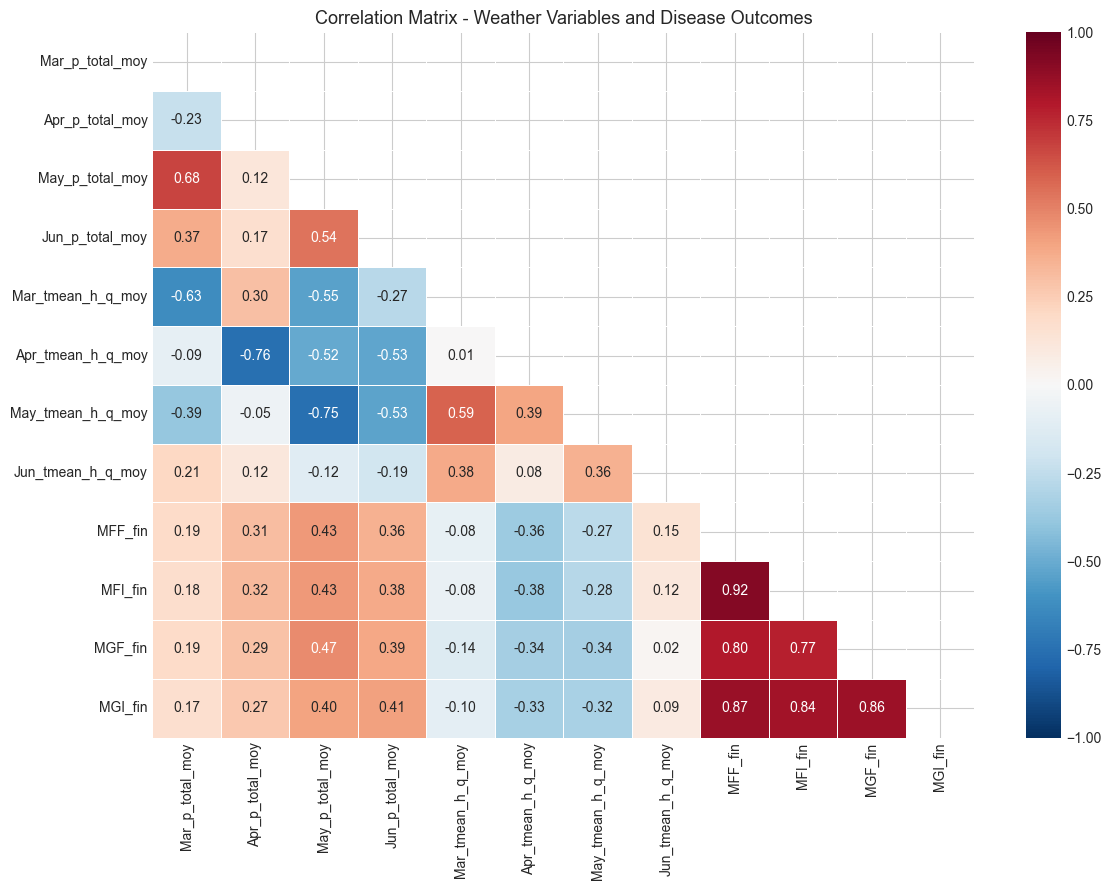

In [24]:
fig, ax = plt.subplots(figsize=(12, 9))

corr = bordeaux[weather_cols + targets].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5
)

ax.set_title("Correlation Matrix - Weather Variables and Disease Outcomes", fontsize=13)
plt.tight_layout()
plt.show()

The strongest correlations with disease outcomes are observerd for May precipitation (r ≈ 0.43–0.47) and April-May temperatures (r ≈ −0.33 to −0.38).
Higher spring rainfall and lower spring temperatures are associated with increased disease incidence. The four outcome variables are strongly inter-correlated (r = 0.77-0.92), suggesting they capture the same underlying disease event from different angles.

### 2.4 Disease Incidence by Year

Proportion of high-incidence records (outcome = 1) per year across all four outcome variables. This reveals whether certain years were systematically worse for disease development.

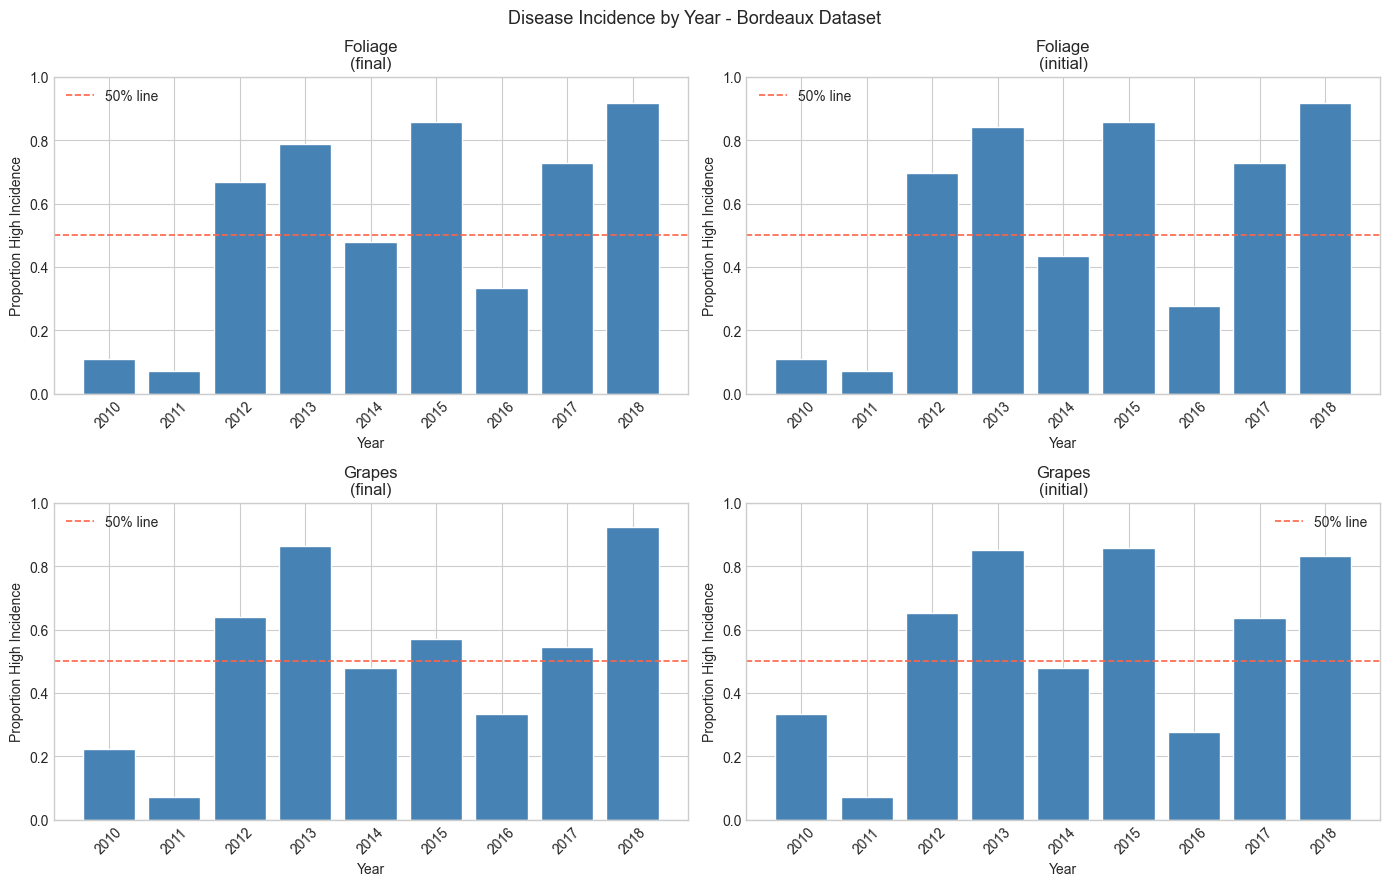

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

year_map = {1: 2010, 2: 2011, 3: 2012, 4: 2013, 5: 2014,
           6: 2015, 7: 2016, 8: 2017, 9: 2018}
bordeaux["Year_actual"] = bordeaux["Year"].map(year_map)

for ax, col, label in zip(axes.flatten(), targets, labels):
    yearly = bordeaux.groupby("Year_actual")[col].mean()
    ax.bar(yearly.index, yearly.values, color="steelblue", edgecolor="white")
    ax.axhline(0.5, color="tomato", linestyle="--", linewidth=1.2, label="50% line")
    ax.set_title(label)
    ax.set_xlabel("Year")
    ax.set_ylabel("Proportion High Incidence")
    ax.set_ylim(0, 1)
    ax.set_xticks(yearly.index)
    ax.set_xticklabels(yearly.index, rotation=45)
    ax.legend()

plt.suptitle("Disease Incidence by Year - Bordeaux Dataset", fontsize=13)
plt.tight_layout()
plt.show()

Disease incidence varies considerably across years and is consistent across all four outcome variables — years with high foliage incidence also tend to show high grape incidence. 2011 stands out as the lowest-incidence year across all outcomes, while 2018 shows the highest. 2016 also recorded notably low incidence despite following two high-incidence years (2014–2015). These inter-annual differences suggest that year-specific weather conditions play a significant role.

## 3. GBIF European Occurence Records

### 3.1 Data Loading & Initial Inspection

The GBIF dataset contains occurence record of *Plasmopara viticola* across Europe, sourced from the Global Biodiversity Information Facility. Each record includes coordinates, observation date and country and country of origin.

In [4]:
gbif = pd.read_csv("../data/raw/gbif_plasmopara_viticola_europe.csv", sep=",", low_memory=False)

print(f"Shape: {gbif.shape}")
print(f"\nColumns:\n{list(gbif.columns)}")
gbif.head()

Shape: (670, 11)

Columns:
['gbifID', 'countryCode', 'stateProvince', 'decimalLatitude', 'decimalLongitude', 'eventDate', 'year', 'month', 'day', 'datasetName', 'basisOfRecord']


,gbifID,countryCode,stateProvince,decimalLatitude,decimalLongitude,eventDate,year,month,day,datasetName,basisOfRecord
0,5231204980,DE,Rheinland-Pfalz,50.245105,7.577645,2025-07-12T10:36,2025.0,7.0,12.0,iNaturalist research-grade observations,HUMAN_OBSERVATION
1,5759905965,AT,Steiermark,46.872512,15.855192,2025-07-27T10:09,2025.0,7.0,27.0,iNaturalist research-grade observations,HUMAN_OBSERVATION
2,5830405532,RU,Tver',56.949115,35.733590,2025-09-20T17:53:59,2025.0,9.0,20.0,iNaturalist research-grade observations,HUMAN_OBSERVATION
3,5889463355,PT,Coimbra,40.154493,-8.711293,2025-10-10T16:33,2025.0,10.0,10.0,iNaturalist research-grade observations,HUMAN_OBSERVATION
4,4863914651,IT,Lombardia,45.003314,9.184298,2024-05-14T10:14:28,2024.0,5.0,14.0,iNaturalist research-grade observations,HUMAN_OBSERVATION


In [5]:
gbif.info()
print("\n")
gbif.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 670 entries, 0 to 669
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gbifID            670 non-null    int64  
 1   countryCode       670 non-null    str    
 2   stateProvince     187 non-null    str    
 3   decimalLatitude   340 non-null    float64
 4   decimalLongitude  340 non-null    float64
 5   eventDate         619 non-null    str    
 6   year              619 non-null    float64
 7   month             580 non-null    float64
 8   day               417 non-null    float64
 9   datasetName       126 non-null    str    
 10  basisOfRecord     670 non-null    str    
dtypes: float64(5), int64(1), str(5)
memory usage: 57.7 KB




gbifID                0
countryCode           0
stateProvince       483
decimalLatitude     330
decimalLongitude    330
eventDate            51
year                 51
month                90
day                 253
datasetName         544
basisOfRecord         0
dtype: int64

In [6]:
gbif.describe().round(2)

,gbifID,decimalLatitude,decimalLongitude,year,month,day
count,6.700000e+02,340.00,340.00,619.00,580.00,417.00
mean,3.894681e+09,49.80,9.98,1957.20,7.72,14.01
std,1.658254e+09,3.77,8.61,54.94,2.45,9.68
min,3.811768e+07,39.54,-21.44,1879.00,1.00,1.00
25%,3.022580e+09,47.12,6.17,1903.00,7.00,5.00
50%,4.099490e+09,50.21,8.03,1957.00,8.00,14.00
75%,5.079602e+09,51.35,13.57,2014.00,9.00,22.00
max,6.189323e+09,66.05,56.11,2025.00,12.00,31.00


### 3.2 Data Quality Assessment

The dataset has significant missing data in severa; columns: 49% of records lack coordinates (unusable for spartial analysis), 13% lack a month value and 38% lack a day value. Critically the `year` column spans from 1879 to 2025, indicating a mix of historical herbarium records and modern citizen-science observation. Records without coordinates will be excluded from spartial and weather-matching analysis; records without month will be excluded from seasonal analyses. No rows are dropped outright - subsets are filtered per task.

### 3.3 Filtering & Cleaning

Records are filtered to 2000-2025 to focus on the modern citizen-science era while retaining sufficient sample size. Pre-2000 records are predominantly historical herbarium speciment with lower coordinate precision and reliability.

In [7]:
gbif_clean = gbif[gbif["year"].between(2000, 2025)].copy()
gbif_clean["year"] = gbif_clean["year"].astype(int)
gbif_clean["month"] = gbif_clean["month"].astype("Int64")

print(f"Records after filtering: {gbif_clean.shape[0]}")
print(f"Records with coordinates: {gbif_clean[['decimalLatitude', 'decimalLongitude']].notna().all(axis=1).sum()}")
print(f"Records with month: {gbif_clean['month'].notna().sum()}")

Records after filtering: 251
Records with coordinates: 229
Records with month: 242


### 3.4 Distribution by Country

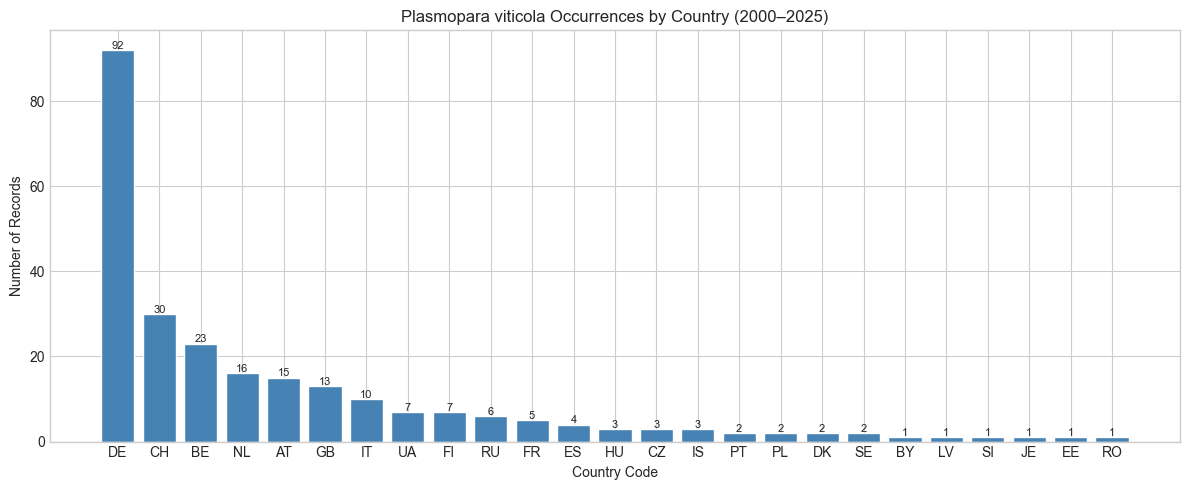

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

country_counts = gbif_clean['countryCode'].value_counts()

ax.bar(country_counts.index, country_counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Country Code')
ax.set_ylabel('Number of Records')
ax.set_title('Plasmopara viticola Occurrences by Country (2000–2025)')

for i, v in enumerate(country_counts.values):
    ax.text(i, v + 0.3, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.show()


Germany (DE) dominates the dataset with 92 recordds (37% of total), followed by Switzerland (CH, 30), Belgium (BE, 23), Netherland (NL, 16) and Austria (AT, 15). Western and Central Europe are well represented, while Southern Europe (ES, PT, IT) and Eastern Europe (RO, HU) have very few records. Bulgaria is absent entirely. This geographic bias reflects the distribution of `iNaturalist` users rather than the actual distribution of the disease - *P. Viticola* is widespread across all European wine-growing regions.

### 3.5 Seasonal Distribution (by Month)

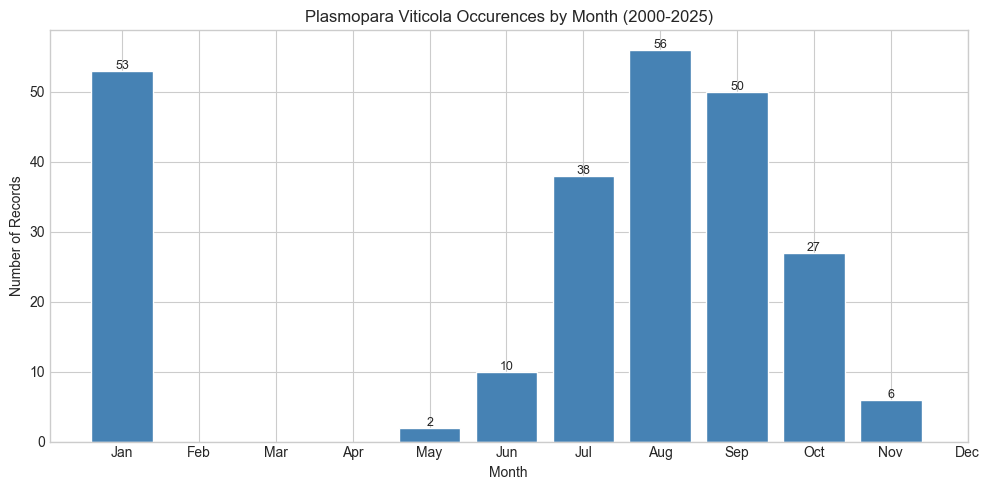

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

month_counts = gbif_clean["month"].value_counts().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

ax.bar(month_counts.index, month_counts.values, color="steelblue", edgecolor="white")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_xlabel("Month")
ax.set_ylabel("Number of Records")
ax.set_title("Plasmopara Viticola Occurences by Month (2000-2025)")

for i, (m, v) in enumerate(month_counts.items()):
    ax.text(m, v + 0.3, str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [11]:
jan_records = gbif_clean[gbif_clean["month"] == 1]
print(f"January records: {len(jan_records)}")
print(f"\neventDate sample:")
print(jan_records["eventDate"].head(10).to_string())

January records: 53

eventDate sample:
136    2014-01-01
137    2014-01-01
138    2014-01-01
139    2014-01-01
140    2014-01-01
141    2014-01-01
142    2014-01-01
143    2014-01-01
144    2014-01-01
145    2014-01-01


In [12]:
print(jan_records["eventDate"].value_counts())

eventDate
2014-01-01    51
2009-01-08     2
Name: count, dtype: int64


In [15]:
gbif_seasonal = gbif_clean[gbif_clean["month"].between(5, 11)].copy()
print(f"Records for seasonal analysis: {len(gbif_seasonal)}")

Records for seasonal analysis: 189


The January spike (53 records) is an artefact: 51 of these share the identical date 2014-01-01, a known GBIF placeholder assighned when no exact date was recorded. The remaining 2 January records (2009-01-08) are biologically implausible for Central Europe where vines are dormant in winter. For seasonal analysis, records are therefore restricted to the grapevine growing season (May-November), reducing the dataset from 242 to 189 records with valid month information

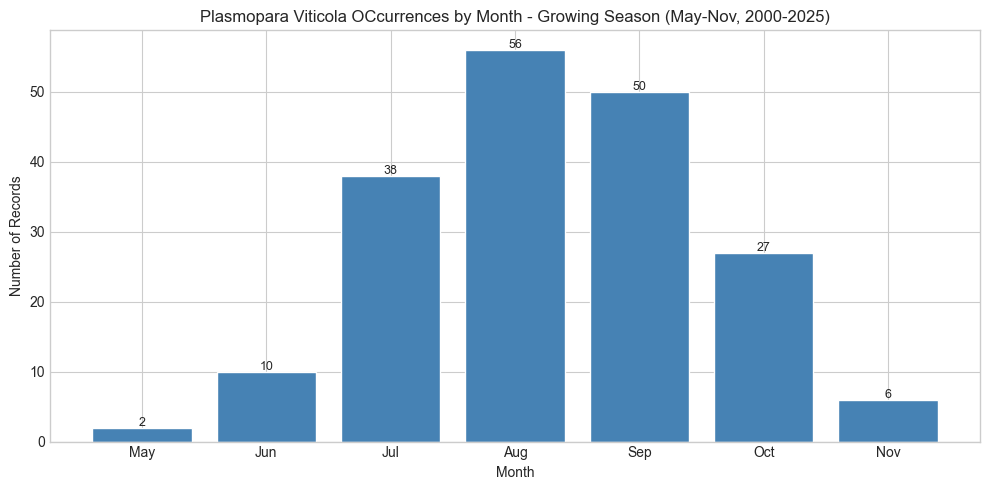

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

month_counts_clean = gbif_seasonal["month"].value_counts().sort_index()

ax.bar(month_counts_clean.index, month_counts_clean.values, color="steelblue", edgecolor="white")
ax.set_xticks(range(5, 12))
ax.set_xticklabels(['May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov'])
ax.set_xlabel("Month")
ax.set_ylabel("Number of Records")
ax.set_title("Plasmopara Viticola OCcurrences by Month - Growing Season (May-Nov, 2000-2025)")

for m, v in month_counts_clean.items():
    ax.text(m, v + 0.3, str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [18]:
nov_records = gbif_seasonal[gbif_seasonal["month"] == 11]
print(nov_records[["eventDate", "countryCode", "stateProvince", "decimalLatitude"]].to_string())

      eventDate countryCode stateProvince  decimalLatitude
100  2020-11-03          DK           NaN        55.672063
197  2013-11-01          CH            Ti        46.156930
198  2013-11-10          CH            Ti        46.063800
199  2013-11-01          CH            Ti        46.201160
209  2012-11-15          CH            Ti        46.201160
213  2010-11-05          CH            Ti        46.199560


After removing placeholder and off-season records, the seasonal distribution shows a clear peak in August (56 records) and September (50 records), with a secondary concentration in July (38). Early-season records (May-June) are sparse, consistent with the time needed for primary infections to develop int visible symptoms.

November sits at the edge of the grapevine growing season, which raised concern about data validity. A closer inspection of the 6 November records revealed distinct, plausable dates across two countries - Switzerland (Ticino, a warm southern alpine region) and Denmark. Given that late-seasaon inflections are biologically possible under warm and wet autumn conditions, these records were retained.

In [24]:
gbif_geo = gbif_clean.dropna(subset=["decimalLatitude", "decimalLongitude"])

m = folium.Map(location=[50, 10], zoom_start=4, tiles="CartoDB positron")

for _, row in gbif_geo.iterrows():
    folium.CircleMarker(
        location=[row["decimalLatitude"], row["decimalLongitude"]],
        radius=4,
        color="steelblue",
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['countryCode']} | {row['year']} | Month: {row['month']}"
    ).add_to(m)

m.save("../notes/gbif_occurrences_map.html")
m

The map confirms the Wetern European bias observed in the country distribution:
the major of records cluster in Germany, Switzerland, Belgium and the Netherlands. Southern European wine regions (France, Italy, Spain) are underrepresented despite being among the most affected areas for `downy mildew`. No records are presented for Bulgaria, which is the focus of the subsequent risk assessment - further underlining that GBIF data reflects observer density rather than true disease distribution.